In [5]:
from pathlib import Path
import pandas as pd

# Load dataset
data_dir = Path("/home/komputer7/SparkProjects/online-retail-pyspark/data")
csv_files = sorted(data_dir.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found under {data_dir}")

dataset_path = csv_files[0]
print(f"Using dataset: {dataset_path}")
df = pd.read_csv(dataset_path)

required_cols = {"InvoiceNo", "StockCode", "Quantity"}
missing_cols = required_cols.difference(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()

Using dataset: /home/komputer7/SparkProjects/online-retail-pyspark/data/staging/online_retail.csv
Rows: 541,909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
import importlib
from itertools import combinations
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
import table_output
importlib.reload(table_output)
from table_output import (
    show_apriori_table,
    build_c1_table,
    build_l1_dropped_table,
    build_c2_table,
    build_l2_table,
    build_c3_table,
    build_l3_final_frequent_itemsets_table,
    build_rules_from_l3_table,
    build_complete_rule_summary_table,
)

# Load source dataset from Cell 1 context.
if 'df' in globals():
    source_df = df.copy()
elif 'dataset_path' in globals():
    source_df = pd.read_csv(dataset_path)
else:
    raise NameError("Run Cell 1 first (or define dataset_path).")

required_cols = {'InvoiceNo', 'StockCode', 'Quantity'}
missing_cols = required_cols.difference(source_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

# Build transaction item representation: StockCode only (stable item identity).
work_df = source_df[['InvoiceNo', 'StockCode', 'Quantity']].copy()
work_df['StockCode'] = work_df['StockCode'].fillna('').astype(str).str.strip()
work_df['Quantity'] = pd.to_numeric(work_df['Quantity'], errors='coerce').fillna(0)
work_df = work_df[(work_df['StockCode'] != '') & (work_df['Quantity'] > 0)].copy()
work_df['InvoiceNo'] = work_df['InvoiceNo'].astype(str).str.strip()
work_df = work_df[~work_df['InvoiceNo'].str.startswith('C')].copy()
work_df['item'] = work_df['StockCode']

transactions = work_df.groupby('InvoiceNo')['item'].apply(lambda s: sorted(set(s))).tolist()
encoder = TransactionEncoder()
encoded = encoder.fit(transactions).transform(transactions)
item_matrix = pd.DataFrame(encoded, columns=encoder.columns_)
num_transactions = len(item_matrix)

print(f"Transactions: {num_transactions}")
print(f"Unique items: {item_matrix.shape[1]}")

# Keep relative support input, then derive absolute support like distributed flow.
min_support = 0.005
abs_support = max(1, int(min_support * num_transactions)) if num_transactions else 1
print(f"Minimum support ratio: {min_support}")
print(f"Absolute minimum support count: {abs_support}")

# Step 1 C1: itemsets, count, support(%).
c1_raw = pd.DataFrame({
    'itemsets': item_matrix.columns,
    'count': item_matrix.sum(axis=0).values,
    'support': (item_matrix.sum(axis=0) / num_transactions).values if num_transactions else 0.0,
}).sort_values(by=['count', 'support'], ascending=False).reset_index(drop=True)

c1_view = show_apriori_table(
    build_c1_table(c1_raw),
    table_id='step1_c1_table',
    table_title='Step 1 C1: Itemsets, Count, Support (%)',
)

# Step 2 L1 prune: use absolute support count threshold.
l1 = c1_raw[c1_raw['count'] >= abs_support].copy().reset_index(drop=True)
dropped_l1 = c1_raw[c1_raw['count'] < abs_support][['itemsets', 'count']].copy().reset_index(drop=True)

l1_dropped_view = show_apriori_table(
    build_l1_dropped_table(dropped_l1),
    table_id='step2_l1_dropped_table',
    table_title='Step 2 Prune -> L1: Dropped Itemsets and Quantity',
)

# Step 3 C2: generate 2-itemsets from L1.
l1_items = l1['itemsets'].tolist()
c2_candidates = list(combinations(l1_items, 2))
c2_records = []
for item_a, item_b in c2_candidates:
    pair_count = int((item_matrix[list((item_a, item_b))].all(axis=1)).sum())
    c2_records.append({
        'itemsets': tuple(sorted((item_a, item_b))),
        'count': pair_count,
        'support': (pair_count / num_transactions) if num_transactions else 0.0,
    })

c2_raw = pd.DataFrame(c2_records, columns=['itemsets', 'count', 'support'])
if not c2_raw.empty:
    c2_raw = c2_raw.sort_values(by=['count', 'support'], ascending=False).reset_index(drop=True)

c2_view = show_apriori_table(
    build_c2_table(c2_raw),
    table_id='step3_c2_table',
    table_title='Step 3 Generate 2-itemsets (C2): itemsets and Count',
)

# Step 4 L2: prune with absolute support count threshold.
l2 = c2_raw[c2_raw['count'] >= abs_support].copy().reset_index(drop=True)

l2_view = show_apriori_table(
    build_l2_table(l2),
    table_id='step4_l2_table',
    table_title='Step 4 All pass -> L2: Frequent 2-itemsets',
)

# Step 5 C3: generate 3-itemsets from L2 join.
if l2.empty:
    c3_raw = pd.DataFrame(columns=['itemsets', 'count', 'support'])
else:
    l2_itemsets = l2['itemsets'].tolist()
    c3_set = set()
    for i in range(len(l2_itemsets)):
        for j in range(i + 1, len(l2_itemsets)):
            merged = tuple(sorted(set(l2_itemsets[i]).union(set(l2_itemsets[j]))))
            if len(merged) == 3:
                c3_set.add(merged)

    c3_records = []
    for triple in sorted(c3_set):
        triple_count = int((item_matrix[list(triple)].all(axis=1)).sum())
        c3_records.append({
            'itemsets': triple,
            'count': triple_count,
            'support': (triple_count / num_transactions) if num_transactions else 0.0,
        })

    c3_raw = pd.DataFrame(c3_records, columns=['itemsets', 'count', 'support'])
    if not c3_raw.empty:
        c3_raw = c3_raw.sort_values(by=['count', 'support'], ascending=False).reset_index(drop=True)

c3_view = show_apriori_table(
    build_c3_table(c3_raw),
    table_id='step5_c3_table',
    table_title='Step 5 Generate 3-itemsets (C3): itemsets, Count, Support (%)',
)

# Step 6 L3: final frequent itemsets (absolute support pruning).
l3 = c3_raw[c3_raw['count'] >= abs_support].copy().reset_index(drop=True)

l3_final_view = show_apriori_table(
    build_l3_final_frequent_itemsets_table(l3),
    table_id='step6_l3_table',
    table_title='Step 6 L3: Final Frequent Itemsets',
)

# Build support lookup from C1/C2/C3 to compute confidence and lift.
support_lookup = {}
for _, row in c1_raw.iterrows():
    support_lookup[frozenset([row['itemsets']])] = float(row['support'])
for _, row in c2_raw.iterrows():
    support_lookup[frozenset(row['itemsets'])] = float(row['support'])
for _, row in c3_raw.iterrows():
    support_lookup[frozenset(row['itemsets'])] = float(row['support'])

# Added Output Table 1: association rules from L3 with confidence + %.
rules_records = []
for _, row in l3.iterrows():
    itemset = frozenset(row['itemsets'])
    support_xy = float(row['support'])
    items = list(itemset)
    for r in range(1, len(items)):
        for antecedent_tuple in combinations(items, r):
            antecedent = frozenset(antecedent_tuple)
            consequent = itemset - antecedent
            support_x = support_lookup.get(antecedent, 0.0)
            support_y = support_lookup.get(consequent, 0.0)
            if support_x <= 0 or support_y <= 0:
                continue
            confidence = support_xy / support_x
            lift = confidence / support_y if support_y > 0 else 0.0
            rules_records.append({
                'antecedent': antecedent,
                'consequent': consequent,
                'support': support_xy,
                'confidence': confidence,
                'lift': lift,
            })

rules_df = pd.DataFrame(
    rules_records,
    columns=['antecedent', 'consequent', 'support', 'confidence', 'lift'],
)
if not rules_df.empty:
    rules_df = rules_df.drop_duplicates(subset=['antecedent', 'consequent']).sort_values(
        by=['confidence', 'lift', 'support'],
        ascending=False,
    ).reset_index(drop=True)

rules_from_l3_view = show_apriori_table(
    build_rules_from_l3_table(rules_df),
    table_id='output_table_1_rules_from_l3',
    table_title='Output Table 1: Generate Association Rules from L3 (Rule, Confidence)',
)

# Added Output Table 2: complete summary table.
complete_summary = build_complete_rule_summary_table(rules_df)
selected_rules_view = show_apriori_table(
    complete_summary,
    table_id='output_table_2_complete_summary',
    table_title='Output Table 2: Complete Summary Table',
)

selected_rules_view

Transactions: 20728
Unique items: 3941
Minimum support ratio: 0.005
Absolute minimum support count: 103


Itemset,Count,Support
85123A,2203,10.63%
85099B,2092,10.09%
22423,1989,9.60%
47566,1686,8.13%
20725,1565,7.55%


Dropped Itemset,Quantity
15044A,102
16225,102
20956,102
21063,102
21617,102


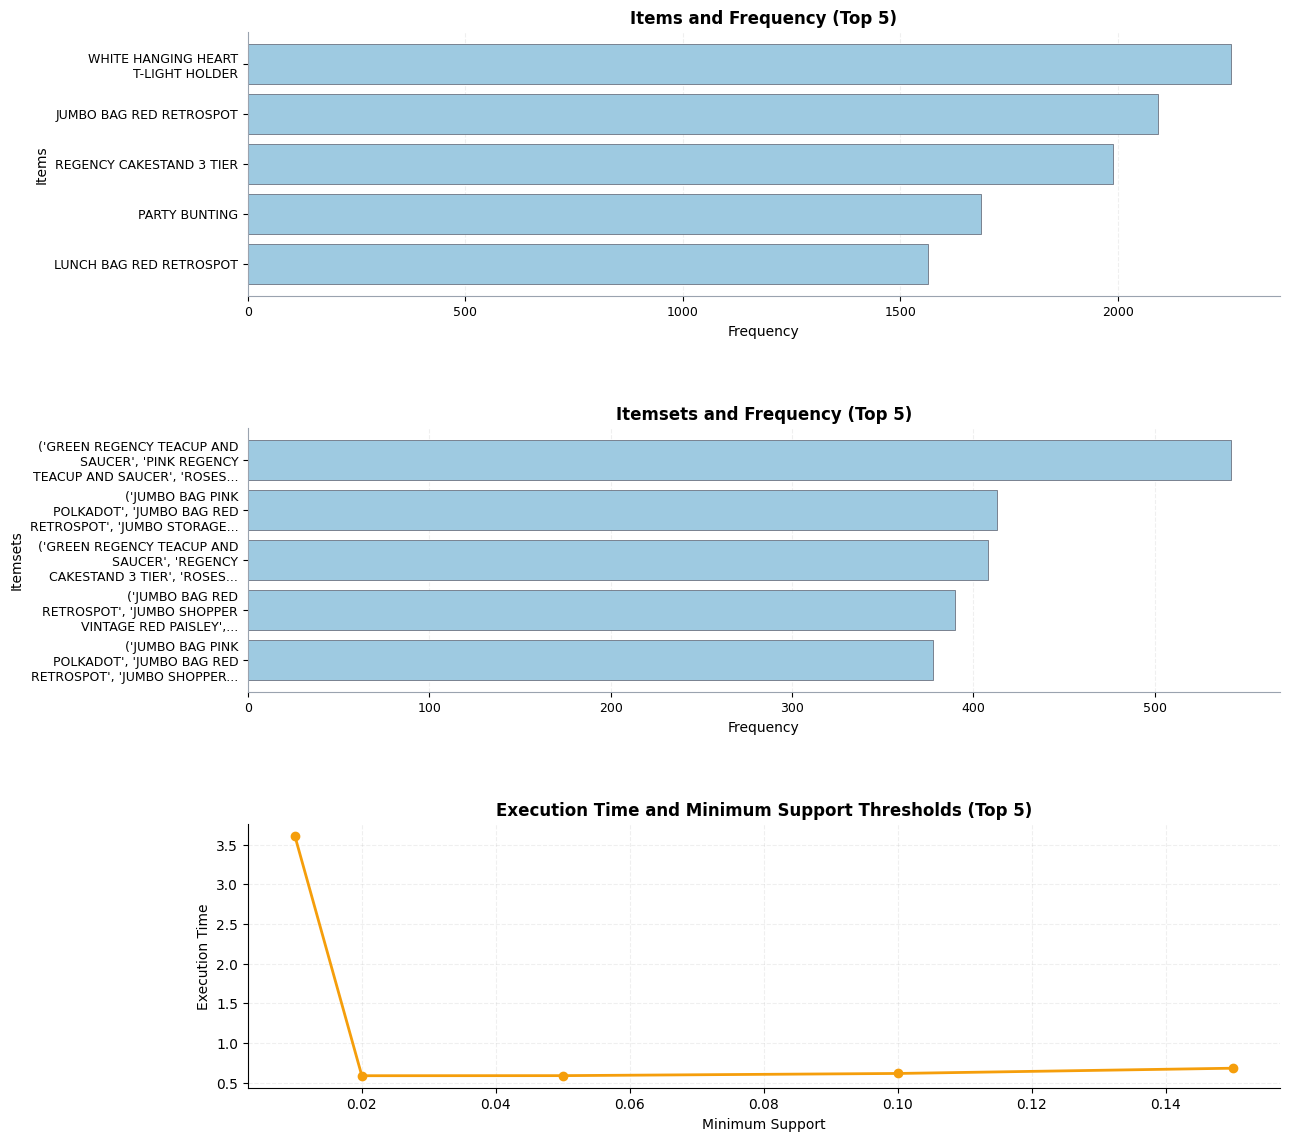

In [27]:
import matplotlib.pyplot as plt
import textwrap


def _resolve_first_frame(*names):
    for name in names:
        frame = globals().get(name)
        if frame is not None and not frame.empty:
            return frame
    return None


def _resolve_column(frame, candidates):
    for column in candidates:
        if column in frame.columns:
            return column
    return None


def _wrap_label(value, width=26, max_lines=3):
    text = str(value)
    wrapped = textwrap.wrap(text, width=width)
    if len(wrapped) > max_lines:
        wrapped = wrapped[:max_lines]
        wrapped[-1] = wrapped[-1].rstrip(".") + "..."
    return "\n".join(wrapped) if wrapped else ""


def _style_barh_axis(axis):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_color("#9aa3af")
    axis.spines["bottom"].set_color("#9aa3af")
    axis.tick_params(axis="x", labelsize=9)
    axis.tick_params(axis="y", labelsize=9)
    axis.grid(axis="x", alpha=0.2, linestyle="--")
    axis.set_axisbelow(True)


def _plot_top5_bars_horizontal(axis, frame, name_col, count_col, title, xlabel, ylabel):
    top_frame = frame.sort_values(by=count_col, ascending=False).head(5).copy()
    top_frame[name_col] = top_frame[name_col].map(lambda value: _wrap_label(value, width=26, max_lines=3))
    axis.barh(top_frame[name_col].astype(str), top_frame[count_col], color="#9ecae1", edgecolor="#6b7280", linewidth=0.6)
    axis.set_title(title, fontsize=12, weight="semibold")
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.invert_yaxis()
    _style_barh_axis(axis)


def _plot_timing_top5(axis, frame, support_col, time_col):
    timing_view = frame.sort_values(by=support_col).head(5).copy()
    axis.plot(timing_view[support_col], timing_view[time_col], marker="o", color="#f59e0b", linewidth=2)
    axis.set_title("Execution Time and Minimum Support Thresholds (Top 5)", fontsize=12, weight="semibold")
    axis.set_xlabel("Minimum Support")
    axis.set_ylabel("Execution Time")
    axis.grid(True, alpha=0.2, linestyle="--")
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


thresholds = globals().get("min_support_thresholds")
show_timing_plot = isinstance(thresholds, (list, tuple)) and len(thresholds) > 1

items_frame = _resolve_first_frame("c1_raw", "c1")
itemsets_frame = _resolve_first_frame("l3")
timing_frame = _resolve_first_frame("workflow_execution_summary") if show_timing_plot else None

if show_timing_plot:
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8.5))

axes = list(axes.ravel()) if hasattr(axes, "ravel") else [axes]
fig.patch.set_facecolor("white")

if items_frame is None:
    axes[0].text(0.5, 0.5, "Run Cell 2 first", ha="center", va="center")
    axes[0].set_axis_off()
else:
    item_name_col = _resolve_column(items_frame, ["itemsets", "itemset", "Itemset", "item"])
    item_count_col = _resolve_column(items_frame, ["count", "Count", "frequency", "qty", "quantity", "item_count"])
    if item_name_col is None or item_count_col is None:
        axes[0].text(0.5, 0.5, "Items data is missing expected columns", ha="center", va="center")
        axes[0].set_axis_off()
    else:
        _plot_top5_bars_horizontal(axes[0], items_frame, item_name_col, item_count_col, "Items and Frequency (Top 5)", "Frequency", "Items")

if itemsets_frame is None:
    axes[1].text(0.5, 0.5, "Run Cell 2 first to build Final Frequent Itemsets", ha="center", va="center")
    axes[1].set_axis_off()
else:
    itemset_name_col = _resolve_column(itemsets_frame, ["itemsets", "itemset", "Itemset"])
    itemset_count_col = _resolve_column(itemsets_frame, ["count", "Count", "frequency", "qty", "quantity"])
    if itemset_name_col is None or itemset_count_col is None:
        axes[1].text(0.5, 0.5, "Final Frequent Itemsets is missing expected columns", ha="center", va="center")
        axes[1].set_axis_off()
    else:
        _plot_top5_bars_horizontal(axes[1], itemsets_frame, itemset_name_col, itemset_count_col, "Itemsets and Frequency (Top 5)", "Frequency", "Itemsets")

if show_timing_plot:
    timing_axis = axes[2]
    if timing_frame is None:
        timing_axis.text(0.5, 0.5, "Run full workflow cell first", ha="center", va="center")
        timing_axis.set_axis_off()
    else:
        support_col = _resolve_column(timing_frame, ["min_support", "minimum_support", "threshold", "support_threshold"])
        time_col = _resolve_column(timing_frame, ["execution_time_sec", "execution_time", "elapsed_time", "duration", "runtime", "seconds", "total_sec"])
        if support_col is None or time_col is None:
            timing_axis.text(0.5, 0.5, "Timing summary is missing expected columns", ha="center", va="center")
            timing_axis.set_axis_off()
        else:
            _plot_timing_top5(timing_axis, timing_frame, support_col, time_col)

fig.subplots_adjust(hspace=0.5, left=0.12, right=0.98, top=0.95, bottom=0.07)
plt.show()


Full Process of Apriori Algorithm (Simple Itemset Focus)

Execution-time benchmark completed.
Edit 'min_support_thresholds' in this cell to test different values.


min_support,execution_time_sec,l1_count,l2_count,l3_count
0.005,1096.547034,1490,7259,5233
0.010,191.307849,790,817,215
0.020,23.268576,276,76,1
0.030,4.192622,119,8,0
0.050,0.338378,32,0,0


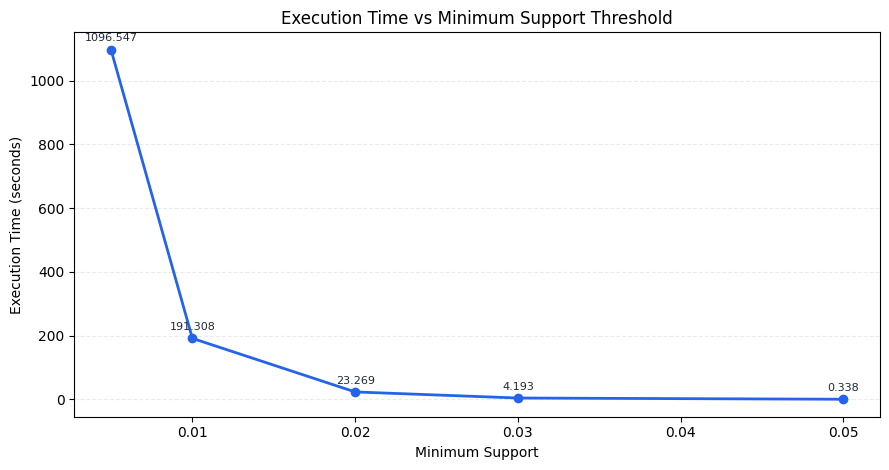


Apriori Implementation Summary (Cell 5)

1. Data Source and Flow
- Uses dataset from Cell 1 (`df` or `dataset_path`).
- Reuses Cell 2 transaction-building logic.
- Produces execution table + one timing chart in Cell 5.

2. Item Representation Used for Calculation
- Required columns: InvoiceNo, StockCode, Quantity.
- Item token formula: StockCode only.
- Filters: Quantity > 0, non-empty StockCode, and non-cancelled invoices.

3. Minimum Support Threshold List
- Configured values: 0.005, 0.010, 0.020, 0.030, 0.050

4. Correlated Itemsets (from frequent L2/L3)
- 22386 + 85099B (k=2, support=0.0398, count=825, threshold=0.005)
- 22697 + 22699 (k=2, support=0.0371, count=768, threshold=0.005)
- 21931 + 85099B (k=2, support=0.0349, count=724, threshold=0.005)
- 22411 + 85099B (k=2, support=0.0328, count=680, threshold=0.005)
- 20725 + 22383 (k=2, support=0.0316, count=655, threshold=0.005)
- 20725 + 20727 (k=2, support=0.0309, count=641, threshold=0.005)
- 22726 + 22727 (k=2, support=0.0309

In [ ]:
# EXECUTION TIME BENCHMARK ACROSS MINIMUM SUPPORT THRESHOLDS
# Flow used: Cell 1 (dataset) -> Cell 2 (transaction matrix logic) -> Cell 3 (visual style direction)

from itertools import combinations
from time import perf_counter
import matplotlib.pyplot as plt
import pandas as pd
from table_output import show_simple_interactive_table

# Keep this list manually editable.
min_support_thresholds = [0.005, 0.01, 0.02, 0.03, 0.05]

# Validate Cell 1 context.
if 'df' in globals():
    source_df = df.copy()
elif 'dataset_path' in globals():
    source_df = pd.read_csv(dataset_path)
else:
    raise NameError("Run Cell 1 first (dataset context missing).")

required_cols = {'InvoiceNo', 'StockCode', 'Quantity'}
missing_cols = required_cols.difference(source_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

# Reuse Cell 2 representation: StockCode-only item model.
work_df = source_df[['InvoiceNo', 'StockCode', 'Quantity']].copy()
work_df['StockCode'] = (
    work_df['StockCode']
    .fillna('')
    .astype(str)
    .str.strip()
)
work_df['Quantity'] = pd.to_numeric(work_df['Quantity'], errors='coerce').fillna(0)
work_df = work_df[(work_df['StockCode'] != '') & (work_df['Quantity'] > 0)].copy()
work_df['InvoiceNo'] = work_df['InvoiceNo'].astype(str).str.strip()
work_df = work_df[~work_df['InvoiceNo'].str.startswith('C')].copy()
work_df['item'] = work_df['StockCode']

transactions = work_df.groupby('InvoiceNo')['item'].apply(lambda s: sorted(set(s))).tolist()
from mlxtend.preprocessing import TransactionEncoder

encoder = TransactionEncoder()
encoded = encoder.fit(transactions).transform(transactions)
item_matrix = pd.DataFrame(encoded, columns=encoder.columns_)
num_transactions = len(item_matrix)

if num_transactions == 0:
    raise ValueError("No transactions found to benchmark.")

execution_records = []
workflow_results = {}

for min_support_value in min_support_thresholds:
    threshold_start = perf_counter()
    abs_support_count = max(1, int(min_support_value * num_transactions))

    # Step 1 C1
    c1_workflow = pd.DataFrame({
        'itemsets': item_matrix.columns,
        'count': item_matrix.sum(axis=0).values,
    })
    c1_workflow['support'] = c1_workflow['count'] / num_transactions

    # Step 2 L1
    l1_workflow = c1_workflow[c1_workflow['count'] >= abs_support_count].copy().reset_index(drop=True)

    # Step 3 C2
    l1_items = l1_workflow['itemsets'].tolist()
    c2_candidates = list(combinations(l1_items, 2))

    c2_records = []
    for item_a, item_b in c2_candidates:
        pair_count = int((item_matrix[[item_a, item_b]].all(axis=1)).sum())
        c2_records.append({
            'itemsets': tuple(sorted((item_a, item_b))),
            'count': pair_count,
            'support': pair_count / num_transactions,
        })

    c2_workflow = pd.DataFrame(c2_records, columns=['itemsets', 'count', 'support'])

    # Step 4 L2
    l2_workflow = c2_workflow[c2_workflow['count'] >= abs_support_count].copy().reset_index(drop=True) if not c2_workflow.empty else pd.DataFrame(columns=['itemsets', 'count', 'support'])

    # Step 5 C3 + L3
    if l2_workflow.empty:
        c3_workflow = pd.DataFrame(columns=['itemsets', 'count', 'support'])
    else:
        l2_itemsets = l2_workflow['itemsets'].tolist()
        c3_set = set()
        for i in range(len(l2_itemsets)):
            for j in range(i + 1, len(l2_itemsets)):
                merged = tuple(sorted(set(l2_itemsets[i]).union(set(l2_itemsets[j]))))
                if len(merged) == 3:
                    c3_set.add(merged)

        c3_records = []
        for triple in c3_set:
            triple_count = int((item_matrix[list(triple)].all(axis=1)).sum())
            c3_records.append({
                'itemsets': triple,
                'count': triple_count,
                'support': triple_count / num_transactions,
            })

        c3_workflow = pd.DataFrame(c3_records, columns=['itemsets', 'count', 'support'])

    l3_workflow = c3_workflow[c3_workflow['count'] >= abs_support_count].copy().reset_index(drop=True) if not c3_workflow.empty else pd.DataFrame(columns=['itemsets', 'count', 'support'])

    total_time = perf_counter() - threshold_start

    execution_records.append({
        'min_support': float(min_support_value),
        'abs_support_count': int(abs_support_count),
        'execution_time_sec': round(total_time, 6),
        'l1_count': int(len(l1_workflow)),
        'l2_count': int(len(l2_workflow)),
        'l3_count': int(len(l3_workflow)),
    })

    workflow_results[min_support_value] = {
        'c1': c1_workflow,
        'l1': l1_workflow,
        'c2': c2_workflow,
        'l2': l2_workflow,
        'c3': c3_workflow,
        'l3': l3_workflow,
        'abs_support_count': int(abs_support_count),
    }

workflow_execution_summary = pd.DataFrame(execution_records).sort_values(by='min_support').reset_index(drop=True)

print("Execution-time benchmark completed.")
print("Edit 'min_support_thresholds' in this cell to test different values.")

# Output table: execution summary only.
workflow_execution_summary_view = show_simple_interactive_table(
    workflow_execution_summary,
    table_id='workflow_execution_summary_table',
    table_title='Execution Time by Minimum Support Threshold',
    max_rows=200,
    page_length=20,
)

# Output visualization: single chart view.
if len(min_support_thresholds) > 1 and not workflow_execution_summary.empty:
    plot_df = workflow_execution_summary[['min_support', 'execution_time_sec']].copy()
    plot_df = plot_df.sort_values(by='min_support').reset_index(drop=True)

    plt.figure(figsize=(9, 4.8))
    plt.plot(plot_df['min_support'], plot_df['execution_time_sec'], marker='o', color='#2563eb', linewidth=2)

    # Label each point for quick read without hover.
    for _, row in plot_df.iterrows():
        plt.annotate(
            f"{row['execution_time_sec']:.3f}",
            (row['min_support'], row['execution_time_sec']),
            textcoords='offset points',
            xytext=(0, 6),
            ha='center',
            fontsize=8,
            color='#1f2937',
        )

    plt.title('Execution Time vs Minimum Support Threshold')
    plt.xlabel('Minimum Support')
    plt.ylabel('Execution Time (seconds)')
    plt.grid(True, axis='y', alpha=0.25, linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print('Execution-time visualization requires more than one minimum support threshold.')

# Build correlated itemset list from frequent pairs/triples found across thresholds.
correlated_records = []
for min_support_value, result in workflow_results.items():
    for level_key in ['l2', 'l3']:
        level_df = result[level_key]
        if level_df is None or level_df.empty:
            continue

        valid_df = level_df[level_df['count'] > 0].copy()
        if valid_df.empty:
            continue

        valid_df = valid_df.sort_values(by=['support', 'count'], ascending=False)
        for _, row in valid_df.head(10).iterrows():
            itemset_value = row['itemsets']
            if isinstance(itemset_value, (tuple, list, set, frozenset)):
                itemset_text = ' + '.join(map(str, itemset_value))
                itemset_size = len(itemset_value)
            else:
                itemset_text = str(itemset_value)
                itemset_size = 1

            correlated_records.append({
                'itemset': itemset_text,
                'itemset_size': itemset_size,
                'support': float(row['support']),
                'count': int(row['count']),
                'min_support': float(min_support_value),
            })

if correlated_records:
    correlated_df = pd.DataFrame(correlated_records)
    correlated_df = correlated_df.sort_values(by=['support', 'count'], ascending=False)
    correlated_df = correlated_df.drop_duplicates(subset=['itemset']).head(10).reset_index(drop=True)
    correlated_lines = '\n'.join(
        [
            f"- {row['itemset']} (k={int(row['itemset_size'])}, support={row['support']:.4f}, count={int(row['count'])}, threshold={row['min_support']:.3f})"
            for _, row in correlated_df.iterrows()
        ]
    )
else:
    correlated_lines = '- No correlated itemsets found (L2/L3 empty for all configured thresholds).'

# Select most valuable rules from the best threshold run.
best_threshold = None
best_rules = pd.DataFrame(columns=['rule', 'support', 'confidence', 'lift'])
best_rule_count = -1

for min_support_value, result in workflow_results.items():
    c1_workflow = result['c1']
    l2_workflow = result['l2']
    l3_workflow = result['l3']

    support_lookup = {}
    for _, row in c1_workflow.iterrows():
        support_lookup[frozenset([row['itemsets']])] = float(row['support'])
    for level_df in [l2_workflow, l3_workflow]:
        if level_df is None or level_df.empty:
            continue
        for _, row in level_df.iterrows():
            support_lookup[frozenset(row['itemsets'])] = float(row['support'])

    frequent_for_rules = pd.concat([l2_workflow, l3_workflow], ignore_index=True)
    if frequent_for_rules.empty:
        continue

    rule_records = []
    for _, row in frequent_for_rules.iterrows():
        items = list(row['itemsets']) if isinstance(row['itemsets'], tuple) else [row['itemsets']]
        itemset_fs = frozenset(items)
        support_xy = float(row['support'])
        if len(itemset_fs) < 2:
            continue

        for r in range(1, len(items)):
            for antecedent_tuple in combinations(items, r):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset_fs - antecedent
                support_x = support_lookup.get(antecedent, 0.0)
                support_y = support_lookup.get(consequent, 0.0)
                if support_x <= 0 or support_y <= 0:
                    continue
                confidence = support_xy / support_x
                lift = confidence / support_y if support_y > 0 else 0.0
                rule_records.append({
                    'rule': f"{' + '.join(sorted(antecedent))} -> {' + '.join(sorted(consequent))}",
                    'support': support_xy,
                    'confidence': confidence,
                    'lift': lift,
                })

    rules_df = pd.DataFrame(rule_records)
    if rules_df.empty:
        continue

    rules_df = rules_df.drop_duplicates(subset=['rule'])
    valuable_rules = rules_df[(rules_df['confidence'] >= 0.70) & (rules_df['lift'] > 1.0)].copy()
    if valuable_rules.empty:
        valuable_rules = rules_df.copy()

    valuable_rules = valuable_rules.sort_values(by=['confidence', 'lift', 'support'], ascending=False).head(10).reset_index(drop=True)

    if len(valuable_rules) > best_rule_count:
        best_rule_count = len(valuable_rules)
        best_threshold = float(min_support_value)
        best_rules = valuable_rules

if not best_rules.empty:
    valuable_rule_lines = '\n'.join(
        [
            f"- {row['rule']} (support={row['support']:.4f}, confidence={row['confidence']:.4f}, lift={row['lift']:.2f})"
            for _, row in best_rules.iterrows()
        ]
    )
else:
    valuable_rule_lines = '- No rules generated from L2/L3 in current threshold list.'

threshold_lines = ', '.join([f"{value:.3f}" for value in min_support_thresholds])

# Detailed summary of implementation.
if not workflow_execution_summary.empty:
    slowest_row = workflow_execution_summary.loc[workflow_execution_summary['execution_time_sec'].idxmax()]
    fastest_row = workflow_execution_summary.loc[workflow_execution_summary['execution_time_sec'].idxmin()]

    summary_text = f"""
Apriori Implementation Summary (Cell 5)

1. Data Source and Flow
- Uses dataset from Cell 1 (`df` or `dataset_path`).
- Reuses Cell 2 transaction-building logic.
- Produces execution table + one timing chart in Cell 5.

2. Item Representation Used for Calculation
- Required columns: InvoiceNo, StockCode, Quantity.
- Item token formula: StockCode only.
- Filters: Quantity > 0, non-empty StockCode, and non-cancelled invoices.

3. Minimum Support Threshold List
- Configured values: {threshold_lines}
- Thresholding uses both ratio and derived absolute support count.

4. Correlated Itemsets (from frequent L2/L3)
{correlated_lines}

5. Most Valuable Rules (Best Threshold Simulation)
- Selected threshold: {best_threshold if best_threshold is not None else 'N/A'}
{valuable_rule_lines}

6. Support, Confidence, Lift Relation to Itemsets
- Support(itemset): frequency of an itemset in all transactions. Formula: support(X) = count(X) / N.
- Confidence(rule X -> Y): conditional strength once itemsets are known. Formula: confidence(X -> Y) = support(X ∪ Y) / support(X).
- Lift(rule X -> Y): association above random co-occurrence. Formula: lift(X -> Y) = support(X ∪ Y) / (support(X) * support(Y)).

7. Performance Observation (Current Run)
- Slowest threshold: {slowest_row['min_support']:.3f} with {slowest_row['execution_time_sec']:.6f} sec.
- Fastest threshold: {fastest_row['min_support']:.3f} with {fastest_row['execution_time_sec']:.6f} sec.
- Lower support usually increases runtime because more candidates survive pruning.
""".strip()

    print("\n" + summary_text)

REPORT GENERATION

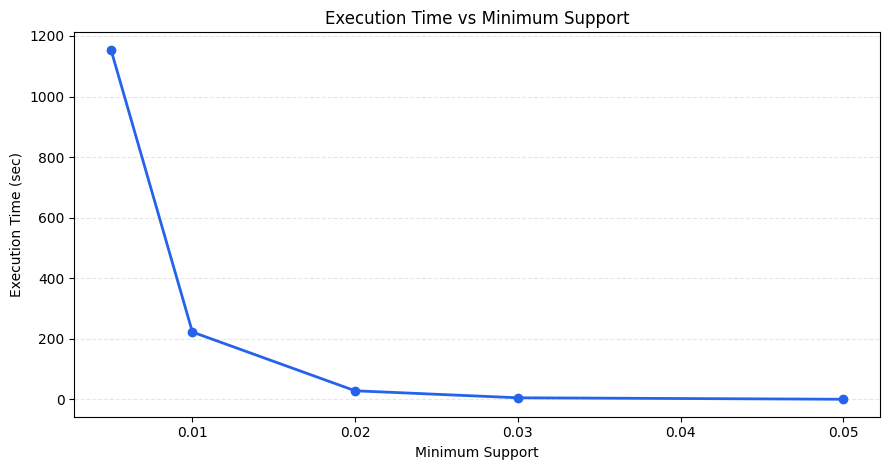

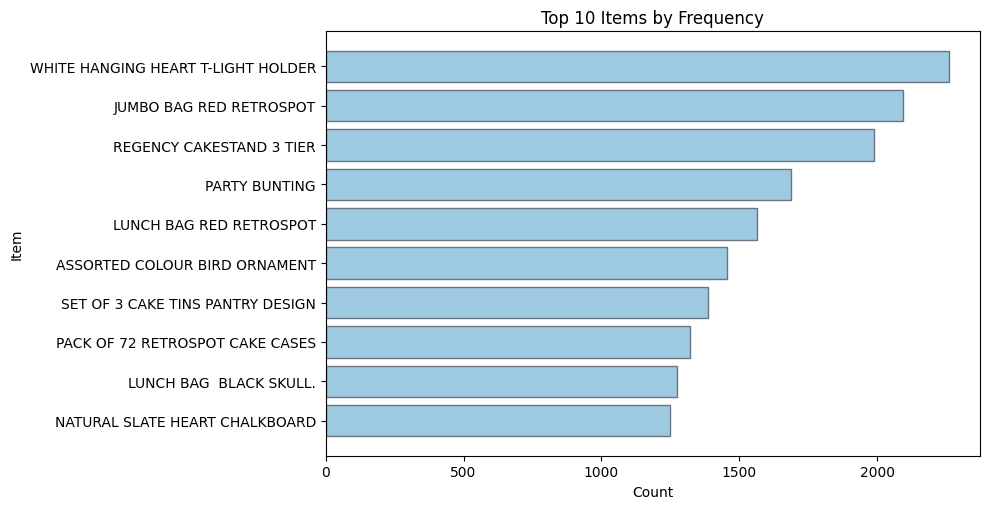

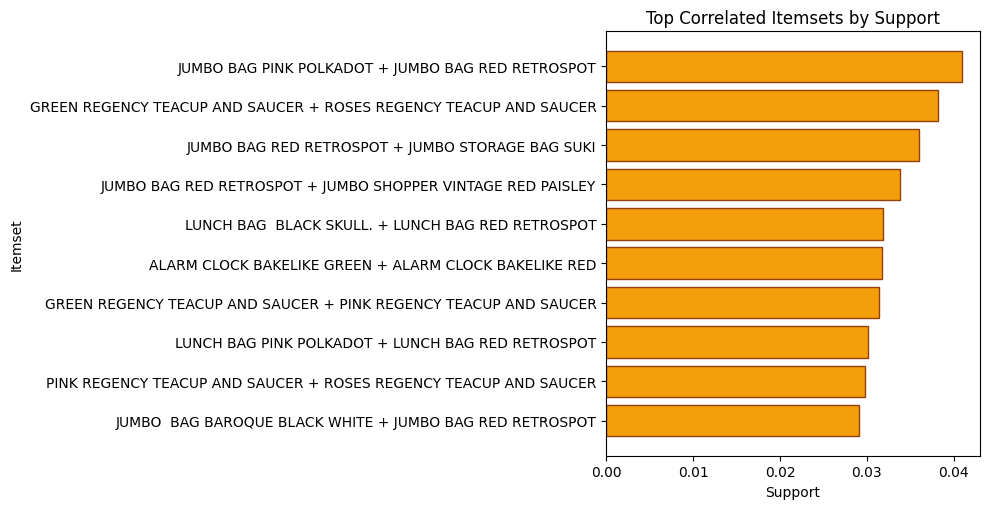

Cell 7: Technical report inputs


,min_support,execution_time_sec,l1_count,l2_count,l3_count
0,0.005,1154.327631,1542,7604,5333
1,0.010,222.332586,803,818,215
2,0.020,28.352296,294,79,3
3,0.030,5.222238,128,8,0
4,0.050,0.390656,33,0,0


,itemsets,count,support
0,WHITE HANGING HEART T-LIGHT HOLDER,2260,0.1122
1,JUMBO BAG RED RETROSPOT,2092,0.1039
2,REGENCY CAKESTAND 3 TIER,1989,0.0988
3,PARTY BUNTING,1686,0.0837
4,LUNCH BAG RED RETROSPOT,1564,0.0777
5,ASSORTED COLOUR BIRD ORNAMENT,1455,0.0723
6,SET OF 3 CAKE TINS PANTRY DESIGN,1385,0.0688
7,PACK OF 72 RETROSPOT CAKE CASES,1320,0.0656
8,LUNCH BAG BLACK SKULL.,1273,0.0632
9,NATURAL SLATE HEART CHALKBOARD,1249,0.0620


,itemset,itemset_size,count,support,min_support
0,JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT,2,825,0.0410,0.005
1,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENC...,2,768,0.0381,0.005
2,JUMBO BAG RED RETROSPOT + JUMBO STORAGE BAG SUKI,2,724,0.0360,0.005
3,JUMBO BAG RED RETROSPOT + JUMBO SHOPPER VINTAG...,2,680,0.0338,0.005
4,LUNCH BAG BLACK SKULL. + LUNCH BAG RED RETROSPOT,2,641,0.0318,0.005
5,ALARM CLOCK BAKELIKE GREEN + ALARM CLOCK BAKEL...,2,640,0.0318,0.005
6,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,2,633,0.0314,0.005
7,LUNCH BAG PINK POLKADOT + LUNCH BAG RED RETROSPOT,2,606,0.0301,0.005
8,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,2,599,0.0297,0.005
9,JUMBO BAG BAROQUE BLACK WHITE + JUMBO BAG RED...,2,585,0.0291,0.005


,rule,support,confidence,lift
0,CHARLIE+LOLA PINK HOT WATER BOTTLE + GREEN REG...,0.0070,1.0000,28.44
1,BEADED CRYSTAL HEART PINK ON STICK + VINTAGE P...,0.0068,1.0000,28.44
2,BEADED CRYSTAL HEART PINK ON STICK + FLORAL FO...,0.0066,1.0000,28.44
3,BEADED CRYSTAL HEART PINK ON STICK + JUMBO BAG...,0.0066,1.0000,28.44
4,BEADED CRYSTAL HEART PINK ON STICK + GREEN REG...,0.0065,1.0000,28.44
5,BEADED CRYSTAL HEART PINK ON STICK + SUKI SHO...,0.0065,1.0000,28.44
6,"BIRTHDAY CARD, RETRO SPOT + SUKI SHOULDER BAG...",0.0064,1.0000,28.44
7,BEADED CRYSTAL HEART PINK ON STICK + JAM MAKIN...,0.0062,1.0000,28.44
8,CHARLIE+LOLA PINK HOT WATER BOTTLE + ROSES REG...,0.0061,1.0000,28.44
9,CARD PARTY GAMES + SUKI SHOULDER BAG -> DOTCO...,0.0060,1.0000,28.44


Technical report generated: /home/komputer7/SparkProjects/online-retail-pyspark/docs/apriori_technical_report_20260607_233348.docx


In [ ]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from docx import Document
    from docx.shared import Inches
except ImportError as exc:
    raise ImportError(
        "python-docx is required for report generation. Install it with: pip install python-docx"
    ) from exc

# Validate required context from previous cells.
required_vars = ["workflow_execution_summary", "min_support_thresholds", "c1_raw"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise NameError(f"Run previous cells first. Missing variables: {missing_vars}")

docs_dir = Path("/home/komputer7/SparkProjects/online-retail-pyspark/docs")
assets_dir = docs_dir / "report_assets"
docs_dir.mkdir(parents=True, exist_ok=True)
assets_dir.mkdir(parents=True, exist_ok=True)

run_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
report_path = docs_dir / f"apriori_technical_report_{run_ts}.docx"

# Prepare report tables.
execution_df = workflow_execution_summary.copy().sort_values("min_support").reset_index(drop=True)
execution_df["min_support"] = execution_df["min_support"].map(lambda v: f"{v:.3f}")
execution_df["execution_time_sec"] = execution_df["execution_time_sec"].map(lambda v: f"{v:.6f}")

top_items_df = c1_raw[["itemsets", "count", "support"]].copy().sort_values("count", ascending=False).head(10).reset_index(drop=True)
top_items_df["support"] = top_items_df["support"].map(lambda v: f"{v:.4f}")

if "correlated_df" in globals() and correlated_df is not None and not correlated_df.empty:
    top_correlated_df = correlated_df[["itemset", "itemset_size", "count", "support", "min_support"]].copy().head(10)
    top_correlated_df["support"] = top_correlated_df["support"].map(lambda v: f"{v:.4f}")
    top_correlated_df["min_support"] = top_correlated_df["min_support"].map(lambda v: f"{v:.3f}")
else:
    top_correlated_df = pd.DataFrame(columns=["itemset", "itemset_size", "count", "support", "min_support"] )

if "best_rules" in globals() and best_rules is not None and not best_rules.empty:
    top_rules_df = best_rules[["rule", "support", "confidence", "lift"]].copy().head(10)
    top_rules_df["support"] = top_rules_df["support"].map(lambda v: f"{v:.4f}")
    top_rules_df["confidence"] = top_rules_df["confidence"].map(lambda v: f"{v:.4f}")
    top_rules_df["lift"] = top_rules_df["lift"].map(lambda v: f"{v:.2f}")
else:
    top_rules_df = pd.DataFrame(columns=["rule", "support", "confidence", "lift"] )

# Build charts for the report.
exec_chart_path = assets_dir / f"execution_time_vs_support_{run_ts}.png"
item_chart_path = assets_dir / f"top_items_frequency_{run_ts}.png"
corr_chart_path = assets_dir / f"top_correlated_itemsets_{run_ts}.png"

exec_chart_df = workflow_execution_summary.copy().sort_values("min_support")
plt.figure(figsize=(9, 4.8))
plt.plot(exec_chart_df["min_support"], exec_chart_df["execution_time_sec"], marker="o", linewidth=2, color="#2563eb")
plt.title("Execution Time vs Minimum Support")
plt.xlabel("Minimum Support")
plt.ylabel("Execution Time (sec)")
plt.grid(True, axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig(exec_chart_path, dpi=150)
plt.show()

item_chart_df = c1_raw.copy().sort_values("count", ascending=False).head(10)
plt.figure(figsize=(10, 5.2))
plt.barh(item_chart_df["itemsets"].astype(str), item_chart_df["count"], color="#9ecae1", edgecolor="#6b7280")
plt.gca().invert_yaxis()
plt.title("Top 10 Items by Frequency")
plt.xlabel("Count")
plt.ylabel("Item")
plt.tight_layout()
plt.savefig(item_chart_path, dpi=150)
plt.show()

if "correlated_df" in globals() and correlated_df is not None and not correlated_df.empty:
    corr_plot_df = correlated_df.copy().sort_values("support", ascending=False).head(10)
    plt.figure(figsize=(10, 5.2))
    plt.barh(corr_plot_df["itemset"].astype(str), corr_plot_df["support"], color="#f59e0b", edgecolor="#92400e")
    plt.gca().invert_yaxis()
    plt.title("Top Correlated Itemsets by Support")
    plt.xlabel("Support")
    plt.ylabel("Itemset")
    plt.tight_layout()
    plt.savefig(corr_chart_path, dpi=150)
    plt.show()
    corr_chart_exists = True
else:
    corr_chart_exists = False

# Notebook outputs (tables).
print("Cell 7: Technical report inputs")
display(execution_df)
display(top_items_df)
display(top_correlated_df)
display(top_rules_df)

def add_df_table(doc, title, df, max_rows=10):
    doc.add_heading(title, level=2)
    if df is None or df.empty:
        doc.add_paragraph("No data available for this section.")
        return

    view_df = df.head(max_rows).copy()
    table = doc.add_table(rows=1, cols=len(view_df.columns))
    table.style = "Table Grid"
    hdr_cells = table.rows[0].cells
    for i, col in enumerate(view_df.columns):
        hdr_cells[i].text = str(col)

    for _, row in view_df.iterrows():
        row_cells = table.add_row().cells
        for i, col in enumerate(view_df.columns):
            row_cells[i].text = str(row[col])

# Build Word report.
doc = Document()
doc.add_heading("Apriori Algorithm Technical Report", level=1)
doc.add_paragraph(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
doc.add_paragraph("Scope: execution-threshold simulation, frequent itemsets, association rules, and significance analysis.")

doc.add_heading("Implementation Summary", level=2)
doc.add_paragraph("1) Item identity: StockCode (cleaned), with Quantity used only for filtering.")
doc.add_paragraph("2) Transaction key: InvoiceNo, excluding cancelled invoices and non-positive quantity rows.")
doc.add_paragraph(f"3) Threshold list used: {', '.join([f'{v:.3f}' for v in min_support_thresholds])}")

doc.add_heading("Significance", level=2)
if not workflow_execution_summary.empty:
    slow_row = workflow_execution_summary.loc[workflow_execution_summary['execution_time_sec'].idxmax()]
    fast_row = workflow_execution_summary.loc[workflow_execution_summary['execution_time_sec'].idxmin()]
    doc.add_paragraph(
        f"Lower support increases candidate growth and runtime. In this run, the slowest threshold is {slow_row['min_support']:.3f} "
        f"({slow_row['execution_time_sec']:.6f} sec), while the fastest threshold is {fast_row['min_support']:.3f} "
        f"({fast_row['execution_time_sec']:.6f} sec)."
    )

if not top_rules_df.empty:
    doc.add_paragraph(
        "Most valuable rules are selected by high confidence and lift (>1). "
        "High confidence indicates strong conditional reliability, and lift > 1 indicates positive association beyond chance."
    )
else:
    doc.add_paragraph(
        "No strong rules were produced in the selected thresholds; reduce minimum support or broaden item grouping to increase co-occurrence."
    )

add_df_table(doc, "Table A: Execution Time by Minimum Support", execution_df, max_rows=20)
add_df_table(doc, "Table B: Top Items by Frequency", top_items_df, max_rows=10)
add_df_table(doc, "Table C: Top Correlated Itemsets", top_correlated_df, max_rows=10)
add_df_table(doc, "Table D: Most Valuable Rules", top_rules_df, max_rows=10)

doc.add_heading("Charts", level=2)
doc.add_paragraph("Chart 1: Execution Time vs Minimum Support")
doc.add_picture(str(exec_chart_path), width=Inches(6.8))
doc.add_paragraph("Chart 2: Top 10 Items by Frequency")
doc.add_picture(str(item_chart_path), width=Inches(6.8))
if corr_chart_exists:
    doc.add_paragraph("Chart 3: Top Correlated Itemsets by Support")
    doc.add_picture(str(corr_chart_path), width=Inches(6.8))

doc.save(report_path)
print(f"Technical report generated: {report_path}")